# FAO GAEZ Land Use Maps Generator
Some outputs from the original data are note ok, so these will be replaced using FAO GAEZ data, including:

|Crop|Reason|
|:---|:-----|
|Oil Palm | Land use raster wrong, missing important production zones like Indonesia|
|Tomatoes| SPAM yields overly high, distorting results for some countries |
|Potatoes| Same as tomatoes |
| Maize | Super high yields |
|Tobacco| High yields |

## Suitability Index Inventory
We start by generating a file with all the files we have

In [86]:
import os
import polars as pl
from pathlib import Path
import numpy as np
import rasterio
import importlib
from rasterio.warp import reproject
from rasterio.enums import Resampling

from sbtn_leaf.paths import data_path
import sbtn_leaf.map_plotting as mp
import sbtn_leaf.cropcalcs as cropcalcs
import sbtn_leaf.RothC_Raster as rothc

project_root = Path.cwd().parents[1]   # adjust number

In [2]:
files_folder = "../data/crops/FAO_GAEZ/SuitIndex"
files_prefix = "GAEZ-V5.RES05-SIX.HP0120.AGERA5.HIST."
files_extension = ".tif"
TEC_LOOKUP = {
    "HILM": "high_input_irrigated",
    "HRLM": "high_input_rainfed",
    "LILM": "low_input_irrigated",
    "LRLM": "low_input_rainfed",
}

IRR_LOOKUP = {
    "HILM": "irr",
    "HRLM": "rf",
    "LILM": "irr",
    "LRLM": "rf",
}

In [3]:
crop_index = pl.read_csv(data_path("crops", "FAO_GAEZ", "FAO_GAEZ_croplist.csv")).drop(["description", "index"]).rename({"caption":"crop_name", "code": "crop_code"})

In [4]:
crop_index.head()

crop_code,crop_name
str,str
"""ALF""","""Alfalfa"""
"""BAN""","""Banana"""
"""BRL""","""Barley"""
"""BSG""","""Biomass sorghum"""
"""BCH""","""Brachiaria"""


In [5]:
folder_path = data_path("crops", "FAO_GAEZ", "SuitIndex")

In [6]:
output_rows = []

for file in os.listdir(folder_path):
    if not file.lower().endswith(".tif"):  # skip not tif files
        continue

    filename = Path(file).stem
    file_path = str(folder_path / Path(file))
    parts = filename.split(".")
    if len(parts) < 2:
            continue
    
    crop_code = parts[-2].strip().upper()
    tech_code = parts[-1].strip().upper()

    output_rows.append({
        "filename": file,
        "filepath": file_path,
        "crop_code": crop_code,
        "tech_code": tech_code,
        "technology": TEC_LOOKUP.get(tech_code),
        "irrigation_practice": IRR_LOOKUP.get(tech_code)
    })

df = pl.DataFrame(output_rows)

# Attach crop names
df = df.join(
     other=crop_index,
     on="crop_code",
     how="left"
)

In [7]:
df.head(2)

filename,filepath,crop_code,tech_code,technology,irrigation_practice,crop_name
str,str,str,str,str,str,str
"""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""ALF""","""HILM""","""high_input_irrigated""","""irr""","""Alfalfa"""
"""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""ALF""","""HRLM""","""high_input_rainfed""","""rf""","""Alfalfa"""


Storing it

In [8]:
csv_out_path = project_root / "data" / "crops" / "FAO_GAEZ" / "fao_gaez_crop_suitindex_list.csv"

df.write_csv(
    str(csv_out_path),
    separator=";"
)

In [9]:
fao_gaez_crops = df["crop_name"].unique()

## Attaching to our analyzed crops

In [38]:
sbtn_crops = pl.read_excel(data_path("crops","FAO_GAEZ", "crops_file_index.xlsx"))

There a few crop names that need adjustment from FAO GAEZ

In [39]:
CROP_RENAME = {
    "Citrus": "Orange",
    "Sugar cane": "Sugarcane",
    "White potato": "Potato",
}

crop_renaming = pl.DataFrame(
    {"fao_gaez_name": ["Citrus","Sugar cane", "White potato"],
    "sbtn_name": ["Orange", "Sugarcane", "Potato"]}
)

Some don't have matches and are kept the same, including:
- Apples
- Grapes

Updating this couple of names

In [12]:
df = (
    df
    .join(
        crop_renaming,
        left_on="crop_name",
        right_on="fao_gaez_name",
        how="left"
    )
    .with_columns(
        pl.coalesce(["sbtn_name", "crop_name"]).alias("crop_name")
    ).drop("sbtn_name")
)

Now, we need only the high input ones

In [13]:
df = df.filter(pl.col("technology").is_in(["high_input_irrigated","high_input_rainfed"]))

Adding the suitability index file

In [15]:
sbtn_crops = sbtn_crops.join(
    other=df,
    how="left",
    on = ["crop_name", "irrigation_practice"]
)

In [16]:
sbtn_crops.head()

crop_name,crop_practice_string,crop_type,irrigation_practice,filename,filepath,crop_code,tech_code,technology,filename_right,filepath_right,crop_code_right,tech_code_right,technology_right
str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""Barley""","""irr_ron""","""annual""","""irr""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""BRL""","""HILM""","""high_input_irrigated""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""BRL""","""HILM""","""high_input_irrigated"""
"""Barley""","""irr_roff""","""annual""","""irr""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""BRL""","""HILM""","""high_input_irrigated""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""BRL""","""HILM""","""high_input_irrigated"""
"""Cabbage""","""irr""","""annual""","""irr""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""CAB""","""HILM""","""high_input_irrigated""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""CAB""","""HILM""","""high_input_irrigated"""
"""Carrot""","""irr""","""annual""","""irr""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""CAR""","""HILM""","""high_input_irrigated""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""CAR""","""HILM""","""high_input_irrigated"""
"""Cotton""","""irr""","""annual""","""irr""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""COT""","""HILM""","""high_input_irrigated""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""COT""","""HILM""","""high_input_irrigated"""


Eliminating apple and grapes

In [17]:
sbtn_crops = sbtn_crops.filter(pl.col("tech_code").is_not_null())

Eliminating duplicated _right columns

In [19]:
sbtn_crops = sbtn_crops.select(
    pl.all().exclude("^.*_right$")
)

## Creating land use maps

### LU Generating function

In [20]:
def create_lu_raster(
    input_fao_raster_path: str,
    output_folder: str,
    output_name: None | str = None,
    fao_raster_str_id: str = "GAEZ-V5.RES05-SIX.HP0120.AGERA5.HIST.",
    uhth_path: str = str(data_path("CountryLayers","soc_uht_map.tif")),
    fao_water: int = 9,
    fao_notsuitable: int = 8,
    fao_si_max: int = 7,
    resampling_method: Resampling = Resampling.mode,
):
    output_folder = Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)

    # --- open base (target grid) ---
    with rasterio.open(uhth_path) as base:
        base_profile = base.profile.copy()
        base_crs = base.crs
        base_transform = base.transform
        base_shape = (base.height, base.width)
        base_nodata = base.nodata

    # --- open FAO raster (source grid) ---
    with rasterio.open(input_fao_raster_path) as fao:
        fao_crs = fao.crs
        fao_transform = fao.transform
        fao_data = fao.read(1)
        fao_nodata = fao.nodata

    # --- build binary on FAO grid ---
    suitable_mask = (
        (fao_data != fao_nodata)
        & (fao_data != fao_water)
        & (fao_data != fao_notsuitable)
        & (fao_data <= fao_si_max)   # <= is usually what you want
    )

    lu_src = np.where(suitable_mask, 1, 0).astype("uint8")

    # --- reproject/resample onto base grid ---
    lu_dst = np.full(base_shape, 0, dtype="uint8")  # binary output; choose 0 as background

    reproject(
        source=lu_src,
        destination=lu_dst,
        src_transform=fao_transform,
        src_crs=fao_crs,
        src_nodata=0,
        dst_transform=base_transform,
        dst_crs=base_crs,
        dst_nodata=0,
        resampling=resampling_method,
    )

    # --- construct output name ---
    if output_name is None:
        fname = Path(input_fao_raster_path).name
        lu_name = fname.split(fao_raster_str_id, 1)[1].rsplit(".tif", 1)[0]
        output_file = f"{lu_name}.tif"
    else:
        output_file = f"{output_name}.tif"

    output_path = f'{output_folder}/{output_file}'

    # --- update profile for binary output ---
    out_profile = base_profile.copy()
    out_profile.update(
        dtype="uint8",
        count=1,
        nodata=0,
        compress="lzw",
    )

    with rasterio.open(output_path, "w", **out_profile) as dst:
        dst.write(lu_dst, 1)

    return str(output_path)


### Going through all the files in the excel

In [21]:
output_folder = str(data_path("land_use","FAO_GAEZ"))

In [ ]:
output_rows = []

for row in sbtn_crops.iter_rows(named=True):
    input_raster = row["filepath"]
    crop_name = row["crop_name"]
    practice_id = row["crop_practice_string"]

    output_name = f"lu_gaez_{crop_name}_{practice_id}"

    print(f"Creating FAO GAEZ v5 based land use map for {crop_name}_{practice_id}")
    lu_path = create_lu_raster(
        input_fao_raster_path = input_raster,
        output_folder = output_folder,
        output_name = output_name
    )

    #add all info to a df
    output_rows.append(
        {"crop_name": crop_name,
        "crop_practice_string": practice_id,
        "lu_file": lu_path}
    )

df_lu_list = pl.dataframe(output_rows)

print("\nFinished!")

Creating FAO GAEZ v5 based land use map for Barley_irr_ron
Creating FAO GAEZ v5 based land use map for Barley_irr_roff
Creating FAO GAEZ v5 based land use map for Cabbage_irr
Creating FAO GAEZ v5 based land use map for Carrot_irr
Creating FAO GAEZ v5 based land use map for Cotton_irr
Creating FAO GAEZ v5 based land use map for Maize_irr_ron
Creating FAO GAEZ v5 based land use map for Maize_irr_roff
Creating FAO GAEZ v5 based land use map for Onion_irr
Creating FAO GAEZ v5 based land use map for Potato_irr
Creating FAO GAEZ v5 based land use map for Rapeseed_irr_ron
Creating FAO GAEZ v5 based land use map for Sorghum_irr_ron
Creating FAO GAEZ v5 based land use map for Sorghum_irr_roff
Creating FAO GAEZ v5 based land use map for Soybean_irr
Creating FAO GAEZ v5 based land use map for Sugar beet_irr
Creating FAO GAEZ v5 based land use map for Sunflower_irr
Creating FAO GAEZ v5 based land use map for Sweet potato_irr
Creating FAO GAEZ v5 based land use map for Tobacco_irr
Creating FAO GAEZ

Checking some outputs

Raster has 1 unique values. Min: 1.00. Max: 1.00


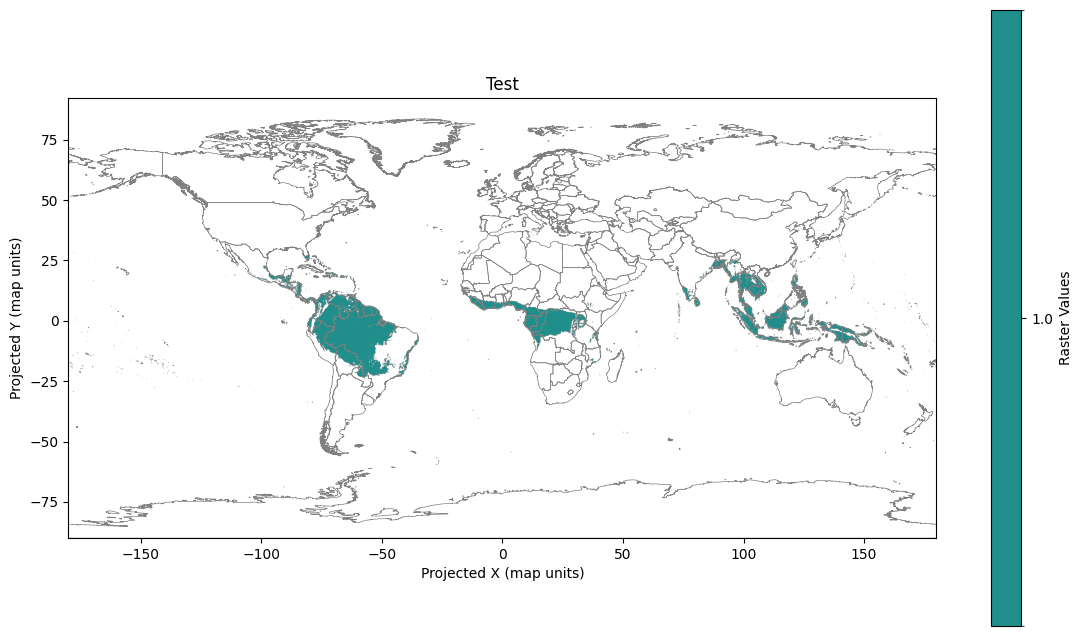

In [41]:
mp.plot_raster_on_world_extremes_cutoff("../../data/land_use/FAO_GAEZ/lu_gaez_Oil palm_rf.tif", "Test")

Raster has 1 unique values. Min: 1.00. Max: 1.00


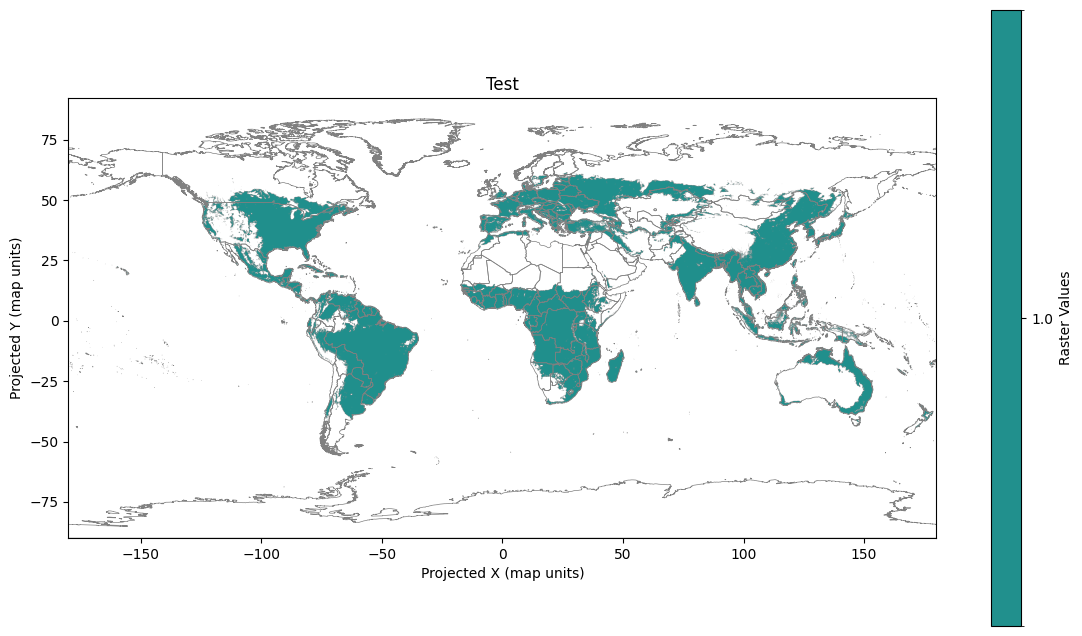

In [24]:
mp.plot_raster_on_world_extremes_cutoff("../../data/land_use/FAO_GAEZ/lu_gaez_Tomato_rf.tif", "Test")

They look good.

Adding the output files to the file inventory

In [42]:
df_lu_files = pl.DataFrame(output_rows)

In [33]:
df_lu_files.head(3)

crop_name,crop_practice_string,lu_file
str,str,str
"""Barley""","""irr_ron""","""C:\Users\loyola\OneDrive - Wor…"
"""Barley""","""irr_roff""","""C:\Users\loyola\OneDrive - Wor…"
"""Cabbage""","""irr""","""C:\Users\loyola\OneDrive - Wor…"


Adding it to sbtn_crops

In [43]:
sbtn_crops = sbtn_crops.join(
    other=df_lu_files,
    how="left",
    on = ["crop_name", "crop_practice_string"]
)

Fixing the column names as some crops - irrigation combinations were missing

In [44]:
sbtn_crops = sbtn_crops.drop("lu_file").rename({"lu_file_right":"lu_file"})

Exporting all this info

In [45]:
sbtn_crops.write_excel(data_path("crops","FAO_GAEZ", "crops_file_index.xlsx"), include_header=True)

## Yields FAO GAEZ Inventory

In [58]:
IRR_YLDS_LOOKUP = {
    "WSI": "Irrigated",
    "WSR": "Rainfed",
    "WST": "Total"
}

IRR_CODE_YLDS_LOOKUP = {
    "WSI": "irr",
    "WSR": "rf",
    "WST": "total"
}

In [73]:
ylds_crops_index = pl.read_excel(data_path("crops", "FAO_GAEZ", "YIELDS", "yields_crops_name_index.xlsx")).sort(by = "crop_code")

In [74]:
ylds_crops_index

crop_code,crop_name,index
str,str,i64
"""ALL""","""All crops""",34
"""BAN""","""Banana and plantain""",1
"""BRL""","""Barley""",2
"""CER""","""Cereals""",36
"""COC""","""Cocoa""",3
…,…,…
"""SUC""","""Sugarcane""",29
"""TEA""","""Tea and mate leaves""",30
"""TOB""","""Tobacco leaves""",31


In [76]:
output_rows = []
folder_path = data_path("crops", "FAO_GAEZ", "YIELDS")

for file in os.listdir(folder_path):
    if not file.lower().endswith(".tif"):  # skip not tif files
        continue

    filename = Path(file).stem  # dropping file extension
    file_path = str(folder_path / Path(file))
    parts = filename.split(".") # splitting based on "."
    if len(parts) < 2:
            continue
    
    crop_code = parts[-2].strip().upper() 
    irr_code = parts[-1].strip().upper()

    output_rows.append({
        "filename": file,
        "filepath": file_path,
        "crop_code": crop_code,
        "irr_code": irr_code,
        "irrigation_practice": IRR_YLDS_LOOKUP.get(irr_code),
        "irrigation_rothc_code": IRR_CODE_YLDS_LOOKUP.get(irr_code),
    })

df_ylds = pl.DataFrame(output_rows)

# Attach crop names
df_ylds = df_ylds.join(
     other=ylds_crops_index,
     on="crop_code",
     how="left"
)

In [77]:
df_ylds.head()

filename,filepath,crop_code,irr_code,irrigation_practice,irrigation_rothc_code,crop_name,index
str,str,str,str,str,str,str,i64
"""GAEZ-V5.RES06-YLD.BAN.WSI.tif""","""C:\Users\loyola\OneDrive - Wor…","""BAN""","""WSI""","""Irrigated""","""irr""","""Banana and plantain""",1
"""GAEZ-V5.RES06-YLD.BAN.WSR.tif""","""C:\Users\loyola\OneDrive - Wor…","""BAN""","""WSR""","""Rainfed""","""rf""","""Banana and plantain""",1
"""GAEZ-V5.RES06-YLD.BAN.WST.tif""","""C:\Users\loyola\OneDrive - Wor…","""BAN""","""WST""","""Total""","""total""","""Banana and plantain""",1
"""GAEZ-V5.RES06-YLD.BRL.WSI.tif""","""C:\Users\loyola\OneDrive - Wor…","""BRL""","""WSI""","""Irrigated""","""irr""","""Barley""",2
"""GAEZ-V5.RES06-YLD.BRL.WSR.tif""","""C:\Users\loyola\OneDrive - Wor…","""BRL""","""WSR""","""Rainfed""","""rf""","""Barley""",2


Transforming to wide with 3 yields columns

In [78]:
df_ylds_wide = df_ylds.select(["crop_name", "irrigation_practice", "filepath"]).pivot(
    on = "irrigation_practice",
    index = "crop_name",
    values="filepath",
    aggregate_function="first"
)

In [79]:
df_ylds_wide.write_csv(data_path("crops","FAO_GAEZ","YIELDS","faogaez_yield_file_index.csv"), separator=";", include_header=True)

## Updated FAO GAEZ & SPAM RothC Inputs

### Creating the needed data inputs

Loading the inventory data file

In [80]:
annual_crops_prep_files = data_path("crops", "rothc_support","annual_crop_rothc_dataprep_inventory_FAOGAEZ.csv")
perm_crops_prep_files = data_path("crops", "rothc_support","permanent_crop_rothc_dataprep_inventory_FAOGAEZ.csv")

In [81]:
annuals_unique_data_prepared = cropcalcs.prepare_crop_scenarios_PET_PlantCover_only(annual_crops_prep_files)

Creating a unique list of rasters with different land use maps...

Preparing irrigation and plant cover data for Barley, irr_ron
Creating PET raster...
PET calculation completed for crop 'Barley' succesfully.
Creating irrigation raster...
Irrigation raster saved to C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\data\crops\rothc_support\FAO_GAEZ\Barley_irr_ron_irr_monthly.tif
Creating plant cover raster...
Plant cover raster saved to C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\data\crops\rothc_support\FAO_GAEZ\Barley_irr_ron_pc_monthly.tif
Irrigation, PET, and plant cover rasters created for Barley, irr_ron!!!
Next!

Preparing irrigation and plant cover data for Cabbage, irr
Creating PET raster...
PET calculation completed for crop 'Cabbage' succesfully.
Creating irrigation raster...
Irrigation raster saved to C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\S

In [53]:
perm_unique_data_prepared = cropcalcs.prepare_crop_scenarios_PET_PlantCover_only(perm_crops_prep_files)

Creating a unique list of rasters with different land use maps...

Preparing irrigation and plant cover data for Banana, irr
Creating PET raster...
PET calculation completed for crop 'Banana' succesfully.
Creating irrigation raster...
Irrigation raster saved to C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\data\crops\rothc_support\FAO_GAEZ\Banana_irr_irr_monthly.tif
Creating plant cover raster...
Plant cover raster saved to C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\data\crops\rothc_support\FAO_GAEZ\Banana_irr_pc_monthly.tif
Irrigation, PET, and plant cover rasters created for Banana, irr!!!
Next!

Preparing irrigation and plant cover data for Cocoa, irr
Creating PET raster...
PET calculation completed for crop 'Cocoa' succesfully.
Creating irrigation raster...
Irrigation raster saved to C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\data\crops\

Exporting both these files

In [56]:
annuals_unique_data_prepared.to_csv(data_path("crops","rothc_support","FAO_GAEZ","annual_crops_FAO_GAEZ_data_path.csv"), sep=";", index=False)
perm_unique_data_prepared.to_csv(data_path("crops","rothc_support","FAO_GAEZ","perm_crops_FAO_GAEZ_data_path.csv"), sep=";", index=False)

### Running RothC

#### Annual Crops - Irrigated

In [149]:
importlib.reload(rothc)
importlib.reload(cropcalcs)

Could not determine dtype for column 1, falling back to string


<module 'sbtn_leaf.cropcalcs' from 'C:\\Users\\loyola\\OneDrive - World Wildlife Fund, Inc\\Documents\\203. Python projects\\SBTN_Test\\src\\sbtn_leaf\\cropcalcs.py'>

In [126]:
annual_crop_rothc_rf_scenarios = "../data/crops/rothc_support/annual_crops_rothc_scenarios_rainfed_FAOGAEZ.xlsx"

In [150]:
rothc.run_rothc_crops_scenarios_from_excel(annual_crop_rothc_rf_scenarios, all_new_files=True, run_test=True)

Could not determine dtype for column 10, falling back to string
Could not determine dtype for column 11, falling back to string
Could not determine dtype for column 12, falling back to string


Running test. Only top 2 scenarios are run. Residue runs forced to 2, years to 5.
Running Annual crop - Barley - rf_ron
    Loading environmental data...
    Loading crop data...
    Running RothC...
        Calculating baseline residue inputs for annual Barley using 2 stochastic runs
shape: (1, 5)
┌────────┬──────┬──────┬──────┬─────┐
│ Crop   ┆ R_AG ┆ RS   ┆ DRY  ┆ R_T │
│ ---    ┆ ---  ┆ ---  ┆ ---  ┆ --- │
│ str    ┆ str  ┆ str  ┆ f64  ┆ str │
╞════════╪══════╪══════╪══════╪═════╡
│ Barley ┆ 1.2  ┆ 0.22 ┆ 0.89 ┆ -   │
└────────┴──────┴──────┴──────┴─────┘
shape: (1, 13)
┌──────────────┬────────┬───────┬───────┬───┬───────────────┬───────────────┬────────────┬─────────┐
│ Climate_Zone ┆ Crop   ┆ K_ini ┆ K_mid ┆ … ┆ Planting_Gree ┆ Soil_Cover_Pe ┆ SCP_Starts ┆ SCP_End │
│ ---          ┆ ---    ┆ ---   ┆ ---   ┆   ┆ nup_Date      ┆ riod          ┆ ---        ┆ ---     │
│ str          ┆ str    ┆ f64   ┆ f64   ┆   ┆ ---           ┆ ---           ┆ i64        ┆ i64     │
│              

RothC months:   0%|          | 0/60 [00:00<?, ?it/s]

Residues month 0, equivalent to annual month 0, average is 0.13
Residues month 1, equivalent to annual month 1, average is 0.42
Residues month 2, equivalent to annual month 2, average is 0.07
Residues month 3, equivalent to annual month 3, average is 0.07
Residues month 4, equivalent to annual month 4, average is 0.16
Residues month 5, equivalent to annual month 5, average is 0.12
Residues month 6, equivalent to annual month 6, average is 0.07
Residues month 7, equivalent to annual month 7, average is 0.07
Residues month 8, equivalent to annual month 8, average is 0.20
Residues month 9, equivalent to annual month 9, average is 0.00
Residues month 10, equivalent to annual month 10, average is 0.13
Residues month 11, equivalent to annual month 11, average is 0.13
Residues month 12, equivalent to annual month 0, average is 0.13
Residues month 13, equivalent to annual month 1, average is 0.42
Residues month 14, equivalent to annual month 2, average is 0.07
Residues month 15, equivalent to 

KeyboardInterrupt: 

Checking results...

In [142]:
soc_bar_rf_roff = project_root / "LEAFs/SOC/rasters/Barley_rf_roff_2021y_SOC.tif"
soc_bar_rf_ron = project_root / "LEAFs/SOC/rasters/Barley_rf_ron_2021y_SOC.tif"

In [143]:
mp.inspect_raster(soc_bar_rf_roff)

File: c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters\Barley_rf_roff_2021y_SOC.tif
Driver: GTiff
Width, Height: 4320, 2083
Number of Bands: 6
CRS: EPSG:4326
Bounds: BoundingBox(left=-179.99999999999997, bottom=-89.99999999999994, right=179.99999999999991, top=83.58333333333331)
Pixel Size: (0.0833333333333333, 0.0833333333333333)
No-data Value: nan

--- Raster Metadata ---
description: RothC results for year 2030 for Barley_rf_roff in ton C/ha
long_name: Soil Organic Carbon
model: RothC rasterized vectorized
units: t C/ha
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float32
  Min Value: 6.972593784332275
  Max Value: 172.4505157470703
  Mean Value: 55.23243713378906
  Standard Deviation: 19.75246810913086

Band 2:
  Data Type: float32
  Min Value: 6.336656093597412
  Max Value: 165.36843872070312
  Mean Value: 52.456478118896484
  Standard Deviation: 19.60322380065918

Band 3:
  Data Type: float32
  M

In [144]:
mp.inspect_raster(soc_bar_rf_ron)

File: c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters\Barley_rf_ron_2021y_SOC.tif
Driver: GTiff
Width, Height: 4320, 2083
Number of Bands: 6
CRS: EPSG:4326
Bounds: BoundingBox(left=-179.99999999999997, bottom=-89.99999999999994, right=179.99999999999991, top=83.58333333333331)
Pixel Size: (0.0833333333333333, 0.0833333333333333)
No-data Value: nan

--- Raster Metadata ---
description: RothC results for year 2030 for Barley_rf_ron in ton C/ha
long_name: Soil Organic Carbon
model: RothC rasterized vectorized
units: t C/ha
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float32
  Min Value: 6.972593784332275
  Max Value: 172.4505157470703
  Mean Value: 55.23243713378906
  Standard Deviation: 19.75246810913086

Band 2:
  Data Type: float32
  Min Value: 7.117734432220459
  Max Value: 165.9586181640625
  Mean Value: 54.39995574951172
  Standard Deviation: 19.097694396972656

Band 3:
  Data Type: float32
  Min 

Raster has 728,122 unique values. Min: 7.63. Max: 167.58
Using quantiles
All positives route (quantiles)


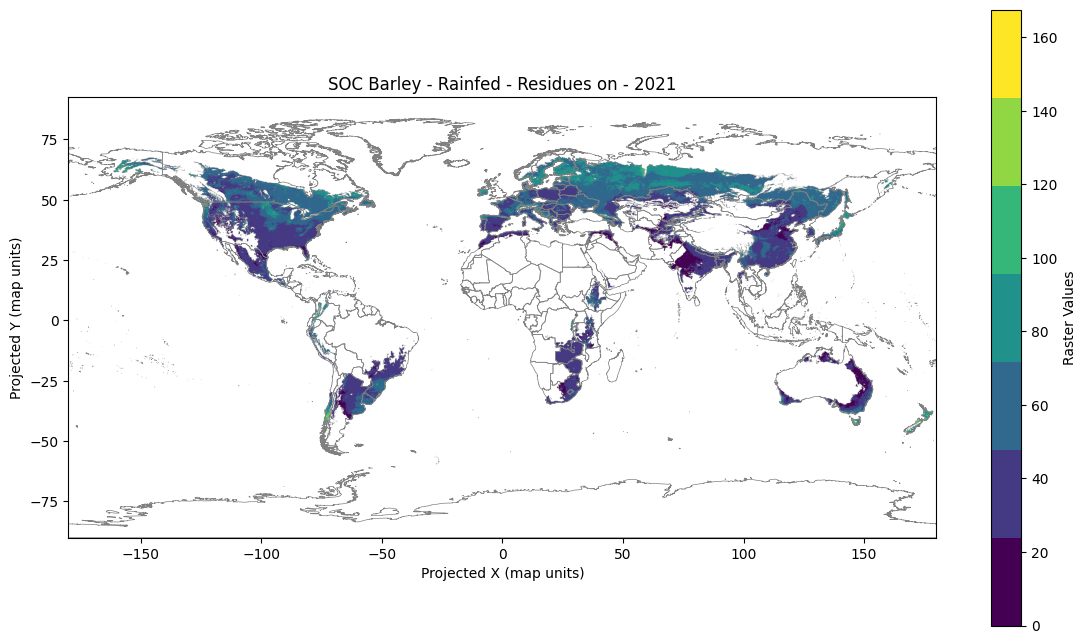

In [145]:
mp.plot_raster_on_world_extremes_cutoff(soc_bar_rf_ron, "SOC Barley - Rainfed - Residues on - 2021", perc_cutoff=0, quantiles=7, raster_band=6)

Raster has 821,389 unique values. Min: 5.24. Max: 158.77
Using quantiles
All positives route (quantiles)


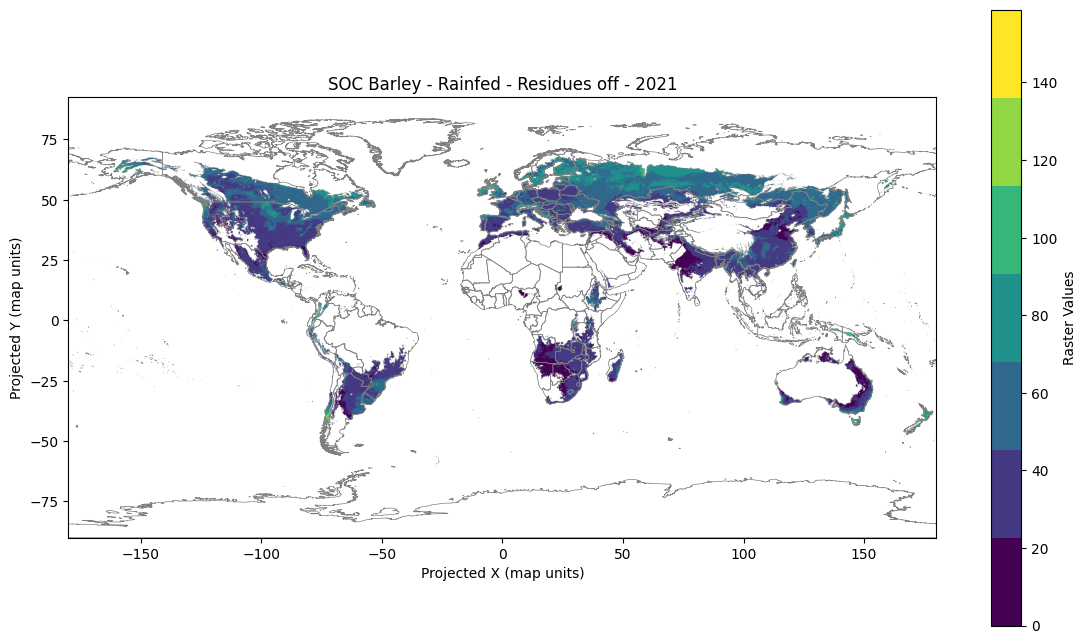

In [146]:
mp.plot_raster_on_world_extremes_cutoff(soc_bar_rf_roff, "SOC Barley - Rainfed - Residues off - 2021", perc_cutoff=0, quantiles=7, raster_band=6)